# Compare Surface Theta @ [timestep] from MIT and OSN data sources

This notebook compares surface-level Theta (k=0) from two different generation pipelines:

- **SRC1** — `generate_global_depth_opt.py` output, reading from MIT-based `s3://dbof/LLC4320_v1`  
  Stored at: `s3://dbof/properties/{run_id}/native_fields.zarr`

- **SRC2** — `generate_global.py` output, reading from OSN-based 
  Stored at: `s3://dbof/native_grid_dbof_training_data/global_20121109_120000/native_fields.zarr`

Both pipelines extract Theta at k=0 and write to the same rectangular LLC4320 layout (12960 x 17280).
The three-panel comparison shows (a) SRC1, (b) SRC2, (c) SRC1 - SRC2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import dbof.dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.dataset_creation.zarr_grid_global    as zarr_grid
import dbof.io.filesystems as filesystems

## Configuration

Edit the run IDs and paths below to match your generation runs.

In [22]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
# ════════════════════════════════════════════════════════════════════════════════

S3_ENDPOINT = "https://s3-west.nrp-nautilus.io"
OSN_ENDPOINT = "https://mghp.osn.xsede.org"

# --- SRC1: generate_global_depth_opt.py output ---
SRC1_BUCKET       = "dbof"
SRC1_FOLDER       = "properties"
SRC1_RUN_ID       = "testing_theta_002"   # <-- update to match your run_id
SRC1_DATASET_NAME = "native_fields.zarr"
SRC1_LABEL        = "depth pipeline (LLC4320_v1)"

# --- SRC2: generate_global.py output ---
SRC2_BUCKET       = "dbof"
SRC2_FOLDER       = "native_grid_dbof_training_data"
SRC2_RUN_ID       = "global_20121106_120000_testing"  # <-- update if different
SRC2_DATASET_NAME = "native_fields.zarr"
SRC2_LABEL        = "global pipeline (OSN/kerchunk)"

# --- S3 timestep store (raw input to depth pipeline) ---
TS_BUCKET = "dbof"
TS_FOLDER = "LLC4320_v1"

# --- Grid ---
GRID_BUCKET       = "dbof"
GRID_FOLDER       = "native_grid_dbof_training_data"
GRID_DATASET_NAME = "llc4320_grid.zarr"

# --- Display ---
CHANNEL   = "Theta"
TIMESTEP  = 0
DS_GLOBAL = 20        # downsample factor for global plots
TARGET_DATE = '2012-11-09 12:00:00'

# ════════════════════════════════════════════════════════════════════════════════

print(f"SRC1 : s3://{SRC1_BUCKET}/{SRC1_FOLDER}/{SRC1_RUN_ID}/{SRC1_DATASET_NAME}")
print(f"SRC2 : s3://{SRC2_BUCKET}/{SRC2_FOLDER}/{SRC2_RUN_ID}/{SRC2_DATASET_NAME}")
print(f"Grid : s3://{GRID_BUCKET}/{GRID_FOLDER}/{GRID_DATASET_NAME}")

SRC1 : s3://dbof/properties/testing_theta_002/native_fields.zarr
SRC2 : s3://dbof/native_grid_dbof_training_data/global_20121106_120000_testing/native_fields.zarr
Grid : s3://dbof/native_grid_dbof_training_data/llc4320_grid.zarr


## Load processed data

In [23]:
# ── Filesystems ────────────────────────────────────────────────────────────────
fs, _ = filesystems.create_s3_filesystems(S3_ENDPOINT)

# ── SRC1 reader ────────────────────────────────────────────────────────────────
reader1 = zarr_dataset.GlobalZarrDatasetReader(
    bucket=SRC1_BUCKET,
    folder=SRC1_FOLDER,
    run_id=SRC1_RUN_ID,
    dataset_name=SRC1_DATASET_NAME,
    fs=fs,
)
print(f"SRC1 channels : {reader1.channel_names}")
print(f"SRC1 shape    : {reader1.shape}  (T, C, H, W)")
print(f"SRC1 times    : {reader1.time[:]}")

# ── SRC2 reader ────────────────────────────────────────────────────────────────
reader2 = zarr_dataset.GlobalZarrDatasetReader(
    bucket=SRC2_BUCKET,
    folder=SRC2_FOLDER,
    run_id=SRC2_RUN_ID,
    dataset_name=SRC2_DATASET_NAME,
    fs=fs,
)
print(f"\nSRC2 channels : {reader2.channel_names}")
print(f"SRC2 shape    : {reader2.shape}  (T, C, H, W)")
print(f"SRC2 times    : {reader2.time[:]}")

# ── Grid ───────────────────────────────────────────────────────────────────────
grid_reader = zarr_grid.GlobalGridZarrReader(
    bucket=GRID_BUCKET,
    folder=GRID_FOLDER,
    dataset_name=GRID_DATASET_NAME,
    fs=fs,
)
XC = grid_reader.lon
YC = grid_reader.lat
print(f"\nGrid loaded: XC {XC.shape}, lon [{XC.min():.1f}, {XC.max():.1f}]  "
      f"YC {YC.shape}, lat [{YC.min():.1f}, {YC.max():.1f}]")

SRC1 channels : ['Theta']
SRC1 shape    : (1, 1, 12960, 17280)  (T, C, H, W)
SRC1 times    : [1463616]

SRC2 channels : ['Theta']
SRC2 shape    : (1, 1, 12960, 17280)  (T, C, H, W)
SRC2 times    : [1453248]

Grid loaded: XC (12960, 17280), lon [-180.0, 180.0]  YC (12960, 17280), lat [-90.0, 72.0]


## Extract Theta snapshots (processed output)

In [24]:
theta_src1 = reader1.get_channel_snapshot(TIMESTEP, CHANNEL)
theta_src2 = reader2.get_channel_snapshot(TIMESTEP, CHANNEL)
theta_diff = theta_src1 - theta_src2

print(f"SRC1 Theta — min: {np.nanmin(theta_src1):.4f}, max: {np.nanmax(theta_src1):.4f}, "
      f"NaN%: {100 * np.isnan(theta_src1).sum() / theta_src1.size:.1f}%")
print(f"SRC2 Theta — min: {np.nanmin(theta_src2):.4f}, max: {np.nanmax(theta_src2):.4f}, "
      f"NaN%: {100 * np.isnan(theta_src2).sum() / theta_src2.size:.1f}%")
print(f"Difference — min: {np.nanmin(theta_diff):.6f}, max: {np.nanmax(theta_diff):.6f}, "
      f"mean: {np.nanmean(theta_diff):.6f}, std: {np.nanstd(theta_diff):.6f}")

# Downsample for plotting
XC_g = XC[::DS_GLOBAL, ::DS_GLOBAL]
YC_g = YC[::DS_GLOBAL, ::DS_GLOBAL]
theta1_g = theta_src1[::DS_GLOBAL, ::DS_GLOBAL]
theta2_g = theta_src2[::DS_GLOBAL, ::DS_GLOBAL]
diff_g   = theta_diff[::DS_GLOBAL, ::DS_GLOBAL]

SRC1 Theta — min: -3.1067, max: 32.9719, NaN%: 43.3%
SRC2 Theta — min: 0.0000, max: 33.0138, NaN%: 55.1%
Difference — min: -9.048548, max: 10.489055, mean: -0.085435, std: 0.648290


## Three panel comparison maps

/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


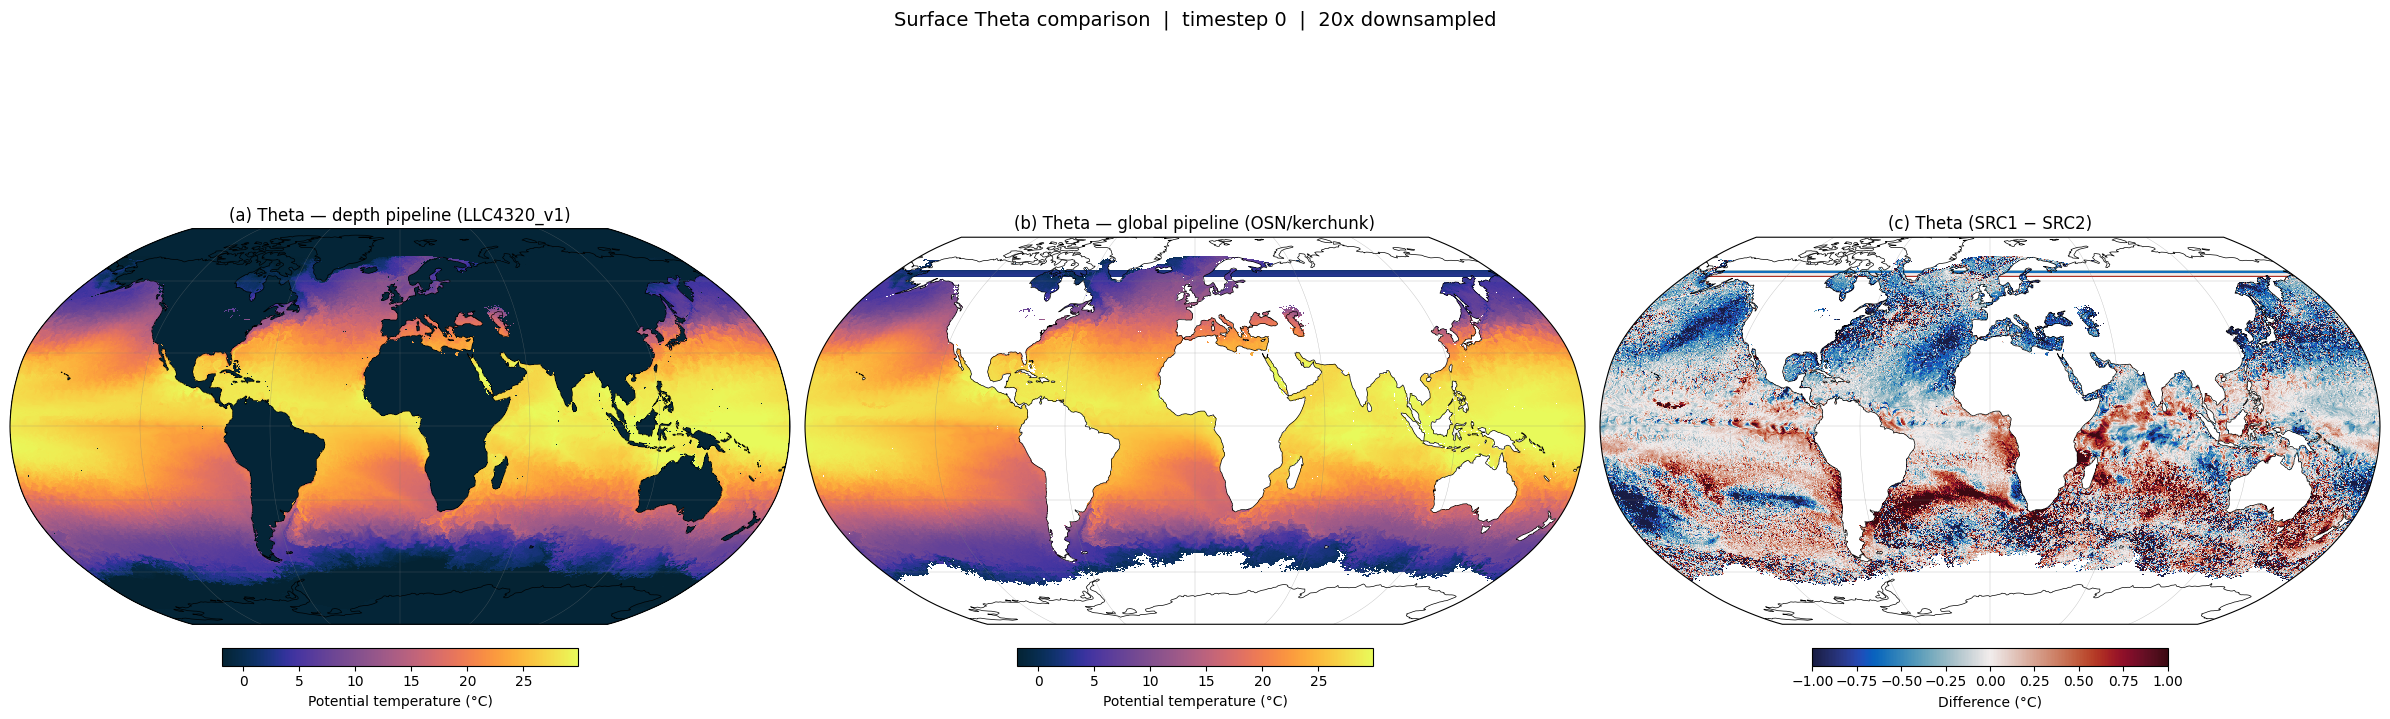

In [25]:
# ── Colour scales ──────────────────────────────────────────────────────────────
all_finite = np.concatenate([
    theta1_g[np.isfinite(theta1_g)],
    theta2_g[np.isfinite(theta2_g)],
])
vmin_theta, vmax_theta = np.nanpercentile(all_finite, [1, 99])

diff_finite = diff_g[np.isfinite(diff_g)]
vlim_diff = np.nanpercentile(np.abs(diff_finite), 99) if diff_finite.size > 0 else 1.0

fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 7),
    subplot_kw={'projection': ccrs.Robinson()},
)

# --- (a) SRC1 ---
ax = axes[0]
im1 = ax.pcolormesh(
    XC_g, YC_g, theta1_g,
    cmap=cmo.thermal, vmin=vmin_theta, vmax=vmax_theta,
    transform=ccrs.PlateCarree(), shading='nearest',
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')
ax.gridlines(linewidth=0.3, color='gray', alpha=0.5)
ax.set_title(f'(a) Theta — {SRC1_LABEL}', fontsize=12)
plt.colorbar(im1, ax=ax, fraction=0.03, pad=0.04, shrink=0.7,
             label='Potential temperature (°C)', orientation='horizontal')

# --- (b) SRC2 ---
ax = axes[1]
im2 = ax.pcolormesh(
    XC_g, YC_g, theta2_g,
    cmap=cmo.thermal, vmin=vmin_theta, vmax=vmax_theta,
    transform=ccrs.PlateCarree(), shading='nearest',
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')
ax.gridlines(linewidth=0.3, color='gray', alpha=0.5)
ax.set_title(f'(b) Theta — {SRC2_LABEL}', fontsize=12)
plt.colorbar(im2, ax=ax, fraction=0.03, pad=0.04, shrink=0.7,
             label='Potential temperature (°C)', orientation='horizontal')

# --- (c) Difference ---
ax = axes[2]
im3 = ax.pcolormesh(
    XC_g, YC_g, diff_g,
    cmap=cmo.balance,
    norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-1, vmax=1),
    transform=ccrs.PlateCarree(), shading='nearest',
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')
ax.gridlines(linewidth=0.3, color='gray', alpha=0.5)
ax.set_title('(c) Theta (SRC1 − SRC2)', fontsize=12)
plt.colorbar(im3, ax=ax, fraction=0.03, pad=0.04, shrink=0.7,
             label='Difference (°C)', orientation='horizontal')

plt.suptitle(
    f'Surface Theta comparison  |  timestep {TIMESTEP}  |  {DS_GLOBAL}x downsampled',
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

## Difference statistics

In [ ]:
diff_full = theta_diff[np.isfinite(theta_diff)]

print(f"Full-resolution difference statistics (SRC1 - SRC2):")
print(f"  N valid pixels : {diff_full.size:,}")
print(f"  Mean           : {diff_full.mean():.8f} °C")
print(f"  Std            : {diff_full.std():.8f} °C")
print(f"  Median         : {np.median(diff_full):.8f} °C")
print(f"  Min            : {diff_full.min():.8f} °C")
print(f"  Max            : {diff_full.max():.8f} °C")
print(f"  MAE            : {np.mean(np.abs(diff_full)):.8f} °C")
print(f"  RMSE           : {np.sqrt(np.mean(diff_full**2)):.8f} °C")

nan1 = np.isnan(theta_src1)
nan2 = np.isnan(theta_src2)
print(f"\nNaN mask comparison:")
print(f"  SRC1 NaN pixels  : {nan1.sum():,}")
print(f"  SRC2 NaN pixels  : {nan2.sum():,}")
print(f"  NaN in both      : {(nan1 & nan2).sum():,}")
print(f"  NaN only in SRC1 : {(nan1 & ~nan2).sum():,}")
print(f"  NaN only in SRC2 : {(~nan1 & nan2).sum():,}")
print(f"  Masks identical  : {np.array_equal(nan1, nan2)}")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(diff_full, bins=200, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel('Theta difference SRC1 - SRC2 (°C)')
ax.set_ylabel('Pixel count')
ax.set_title('Distribution of Theta differences (full resolution)')
ax.set_yscale('log')
plt.tight_layout()
plt.show()